# Chapter 1 — Neural Networks from Scratch

A five-module chapter for engineers who already know linear algebra,
optimization loops, and classical ML, and who want to understand deep learning
by **building it**. Nothing here is imported before it has been written by hand.

| Module | What you build | Tools |
|---|---|---|
| 1 | A single neuron, trained with manual gradient descent | NumPy |
| 2 | A multi-layer perceptron with hand-written backpropagation | NumPy |
| 3 | The same architecture in a production framework | TensorFlow/Keras |
| 4 | Hyperparameter & overfitting experiments | Keras |
| 5 | An end-to-end tabular pipeline (churn prediction) | Scikit-Learn + Keras |

**How each concept is presented.** Every core idea comes in three passes, in
this order:

> 🧠 **The intuition:** the idea in plain language, no symbols.
> 📐 **The math:** the same idea written precisely, so you can read papers.
> 💻 **The code:** the same idea again, executable, in the cell that follows.

If a formula doesn't land, drop back to the intuition above it and read
forward again; they are three descriptions of one thing, not three topics.

**How to use this notebook:** run every cell top to bottom once, then go back
and break things. Each module ends with *Experiments*, which is where the
real learning happens.

**Runtime:** a couple of minutes on CPU. All data is synthetic and generated
in-notebook, so everything is reproducible and nothing downloads.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=42)      # one seeded generator for the whole notebook -> reproducible runs
plt.rcParams["figure.figsize"] = (7, 4.5)  # default size for every figure
plt.rcParams["axes.grid"] = True           # light gridlines on all plots
print("NumPy", np.__version__)

NumPy 2.5.1


---
# Module 1 — A Single Neuron from Scratch

🧠 **The intuition.** A neuron is a voter with adjustable prejudices. It reads
the input features, weighs each one by how much it cares, adds a fixed offset,
and squashes the total into a number between 0 and 1 that reads as "how
confident am I that this is a positive example". Learning means adjusting those
weights until the confidences match reality.

📐 **The math.** That description is a linear model pushed through a squashing
function:

$$\hat{y} = \sigma(w^\top x + b), \qquad \sigma(z) = \frac{1}{1 + e^{-z}}$$

A dot product, a bias, and a nonlinearity. If you have fit logistic regression
before, you have already trained a single neuron, and deep learning starts by
stacking these.

💻 **The code**, spread over the six sections below. We train with **binary
cross-entropy** (BCE) loss and plain gradient descent, computing every gradient
by hand. No framework, no autodiff, nothing hidden.

## 1.1 Synthetic data: two linearly separable blobs

Two Gaussian clusters in 2-D, 100 samples. A single neuron can only draw a
straight-line boundary, so we make the problem linearly separable on purpose.

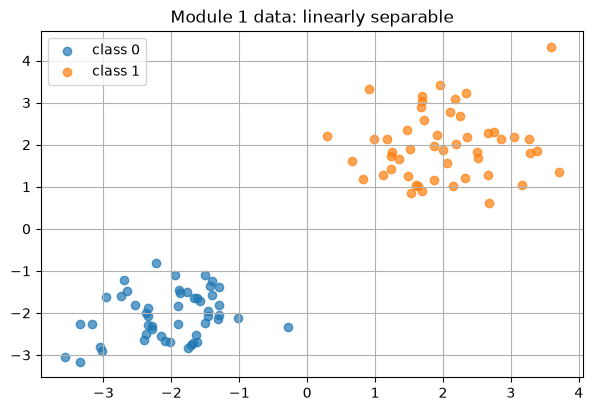

X1: (100, 2)  y1: (100,)


In [2]:
n_per_class = 50

# rng.normal draws Gaussian samples: loc = cluster center, scale = spread,
# size = (rows, columns) -> 50 points with 2 features each
X_a = rng.normal(loc=[-2.0, -2.0], scale=0.8, size=(n_per_class, 2))
X_b = rng.normal(loc=[+2.0, +2.0], scale=0.8, size=(n_per_class, 2))

X1 = np.vstack([X_a, X_b])   # stack rows: (50, 2) on top of (50, 2) -> (100, 2)
y1 = np.concatenate([np.zeros(n_per_class), np.ones(n_per_class)])  # 50 zeros then 50 ones

# Shuffle so the classes are interleaved
perm = rng.permutation(len(X1))   # a random ordering of the indices 0..99
X1, y1 = X1[perm], y1[perm]       # indexing by `perm` applies the same shuffle to X and y

plt.scatter(X1[y1 == 0, 0], X1[y1 == 0, 1], label="class 0", alpha=0.7)
plt.scatter(X1[y1 == 1, 0], X1[y1 == 1, 1], label="class 1", alpha=0.7)
plt.legend(); plt.title("Module 1 data: linearly separable"); plt.show()
print("X1:", X1.shape, " y1:", y1.shape)

## 1.2 Initialize parameters and write the forward pass

The forward pass for **all 100 samples at once** is a single matrix-vector
product: `z = X @ w + b`. Vectorizing over the batch dimension is the core
mechanical skill of this whole curriculum: no Python loops over samples, ever.

In [3]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def forward_neuron(X, w, b):
    z = X @ w + b        # (n, 2) @ (2,) + scalar -> (n,)
    return sigmoid(z)    # predicted probability of class 1

# Small random weights, zero bias
w = rng.normal(scale=0.01, size=2)
b = 0.0

y_hat = forward_neuron(X1, w, b)
print("first 5 predictions:", np.round(y_hat[:5], 3))
print("(all ~0.5: the untrained neuron knows nothing yet)")

first 5 predictions: [0.5   0.499 0.5   0.501 0.5  ]
(all ~0.5: the untrained neuron knows nothing yet)


## 1.3 Binary cross-entropy loss

🧠 **The intuition.** The loss has to answer "how wrong was that guess?", and
it must punish *confident* wrongness far more harshly than hesitant wrongness.
Saying "0.6" about a positive example is a shrug; saying "0.01" is a claim, and
a wrong claim should be expensive.

📐 **The math.**

$$L = -\frac{1}{n}\sum_{i=1}^{n} \Big[ y_i \log \hat{y}_i + (1-y_i)\log(1-\hat{y}_i) \Big]$$

Put numbers through it. True label 1, prediction 0.99: the per-sample loss is
$-\log(0.99) \approx 0.01$, essentially free. True label 1, prediction 0.01:
$-\log(0.01) \approx 4.6$. The logarithm is what makes the penalty for
confident wrongness grow without bound.

💻 **The code.** We clip predictions away from exactly 0 and 1 so `log` never
sees zero.

In [4]:
def bce_loss(y_true, y_pred):
    eps = 1e-12
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

print("loss with random weights:", bce_loss(y1, y_hat))
print("baseline -log(0.5)      :", -np.log(0.5), " (pure guessing)")

loss with random weights: 0.6935000762167182
baseline -log(0.5)      : 0.6931471805599453  (pure guessing)


## 1.4 Gradients, by hand

🧠 **The intuition.** To improve, each weight needs to know which way to move
and by how much, which is what a gradient is. The remarkable thing about the
sigmoid/BCE pairing is that after the calculus settles, the answer is the
simplest quantity in the problem: **how far off the prediction was**. Nothing
else survives.

📐 **The math.** We need $\partial L / \partial w$ and $\partial L / \partial b$.
With $z = w^\top x + b$ and $\hat{y} = \sigma(z)$:

$$\frac{\partial L}{\partial z} = \hat{y} - y$$

The messy $\sigma'(z)$ term cancels against the derivative of the log, which is
precisely *why* BCE is the standard partner for sigmoid, and it is worth
deriving once on paper. Then the chain rule gives:

$$\frac{\partial L}{\partial w} = \frac{1}{n} X^\top(\hat{y} - y), \qquad
  \frac{\partial L}{\partial b} = \frac{1}{n}\sum_i (\hat{y}_i - y_i)$$

The update step is classic gradient descent: $w \leftarrow w - \eta \, \partial L / \partial w$.

💻 **The code.**

In [5]:
def neuron_gradients(X, y_true, y_pred):
    n = len(y_true)
    error = y_pred - y_true          # (n,)  <- dL/dz for each sample
    grad_w = X.T @ error / n         # (2,)
    grad_b = np.mean(error)          # scalar
    return grad_w, grad_b

# Sanity-check against a numerical gradient (finite differences).
# If these agree to ~7 decimal places, our calculus is right.
def numerical_grad_w(X, y, w, b, i, h=1e-6):
    w_plus, w_minus = w.copy(), w.copy()
    w_plus[i] += h; w_minus[i] -= h
    return (bce_loss(y, forward_neuron(X, w_plus, b)) -
            bce_loss(y, forward_neuron(X, w_minus, b))) / (2 * h)

gw, gb = neuron_gradients(X1, y1, forward_neuron(X1, w, b))
print("analytic  dL/dw:", gw)
print("numerical dL/dw:", [numerical_grad_w(X1, y1, w, b, i) for i in (0, 1)])

analytic  dL/dw: [-1.01005023 -1.00660338]
numerical dL/dw: [np.float64(-1.010050226790682), np.float64(-1.0066033758193704)]


## 1.5 The training loop

Everything above, repeated: forward → loss → gradients → update. Watch the loss
fall from ~0.69 (coin-flip) toward 0.

final loss = 0.0023   accuracy = 100%
learned w = [1.8064474  1.87376387],  b = 0.098


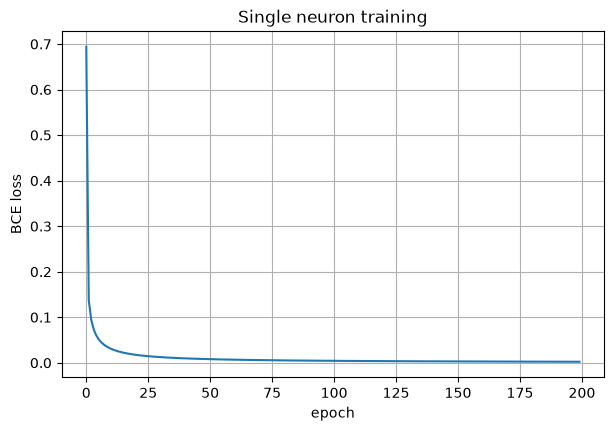

In [6]:
w = rng.normal(scale=0.01, size=2)
b = 0.0
learning_rate = 0.5
losses = []

for epoch in range(200):
    y_hat = forward_neuron(X1, w, b)          # forward
    losses.append(bce_loss(y1, y_hat))        # measure
    grad_w, grad_b = neuron_gradients(X1, y1, y_hat)  # backward
    w -= learning_rate * grad_w               # update
    b -= learning_rate * grad_b

accuracy = np.mean((forward_neuron(X1, w, b) > 0.5) == y1)
print(f"final loss = {losses[-1]:.4f}   accuracy = {accuracy:.0%}")
print(f"learned w = {w},  b = {b:.3f}")

plt.plot(losses)
plt.xlabel("epoch"); plt.ylabel("BCE loss"); plt.title("Single neuron training"); plt.show()

## 1.6 What did it learn?

The boundary is the line where $w^\top x + b = 0$ (probability exactly 0.5).
We visualize the neuron's probability surface over the whole plane.

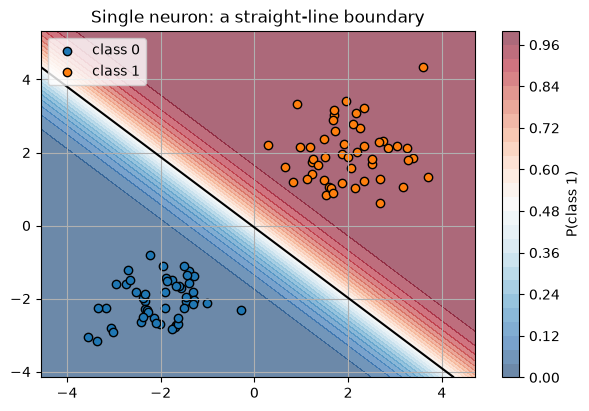

In [7]:
def plot_decision_boundary(predict_fn, X, y, title):
    # Idea: evaluate the model at every point of a dense grid covering the data,
    # then draw the predicted probability as a colored background.
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),   # meshgrid: 200x200 lattice of
                         np.linspace(y_min, y_max, 200))   #   (x, y) coordinate matrices
    grid = np.c_[xx.ravel(), yy.ravel()]        # flatten + pair columns -> (40000, 2) batch of points
    probs = predict_fn(grid).reshape(xx.shape)  # predict all 40k at once, reshape back onto the grid
    plt.contourf(xx, yy, probs, levels=25, cmap="RdBu_r", alpha=0.6)  # filled contours = probability heatmap
    plt.colorbar(label="P(class 1)")
    plt.contour(xx, yy, probs, levels=[0.5], colors="k", linewidths=1.5)  # the P=0.5 line IS the decision boundary
    plt.scatter(X[y == 0, 0], X[y == 0, 1], edgecolor="k", label="class 0")
    plt.scatter(X[y == 1, 0], X[y == 1, 1], edgecolor="k", label="class 1")
    plt.legend(); plt.title(title); plt.show()

plot_decision_boundary(lambda G: forward_neuron(G, w, b), X1, y1,
                       "Single neuron: a straight-line boundary")

## 1.7 Experiments (Module 1)

1. **Learning rate:** rerun 1.5 with `learning_rate = 0.01` and `= 5.0`. How many
   epochs until loss < 0.1 in each case?
2. **No bias:** fix `b = 0` and never update it. Shift both blobs by `+3` in each
   coordinate and retrain. Why does it fail now? (Hint: where must a bias-free
   boundary pass through?)
3. **Overlap:** regenerate the data with `scale=2.5`. The classes now overlap, so
   watch what happens to final loss and accuracy. The neuron isn't broken; the
   *problem* has irreducible error.

---
# Module 2 — A Multi-Layer Perceptron from Scratch

🧠 **The intuition.** One neuron draws one straight line, so any problem whose
boundary curves is out of reach. The fix is to hire a committee: a layer of
neurons, each drawing its own line, and then a final neuron that decides how to
combine their verdicts. Because the committee members are themselves trainable,
the model **learns its own features** rather than waiting for you to engineer
them. That sentence is most of what "deep" buys you.

📐 **The math.** Two layers instead of one:

$$h = \mathrm{ReLU}(X W_1 + b_1) \qquad \hat{y} = \sigma(h W_2 + b_2)$$

- **Hidden layer** $W_1$: (2 → 16), so 16 neurons, each drawing its own line;
  ReLU ($\max(0, z)$) turns each into a "half-plane detector".
- **Output layer** $W_2$: (16 → 1), a single neuron that *combines the 16
  detectors*, exactly the neuron from Module 1, with the hidden activations as
  its input features.

The price of the extra layer: gradients must now flow *through* it. That is
**backpropagation**, which is nothing more than the chain rule applied layer by
layer, backwards.

💻 **The code.** A harder dataset first, then forward, then backward, then a
numerical check that the backward pass is actually correct.

## 2.1 Non-linear data: two interleaved moons

No straight line separates these, so Module 1's neuron is guaranteed to fail
here.

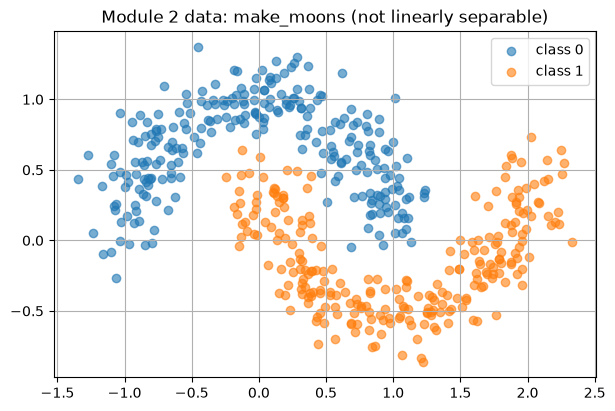

In [8]:
from sklearn.datasets import make_moons

# make_moons generates two interleaving half-circles, the classic non-linear toy set.
# noise = std-dev of Gaussian jitter on each point; returns X (n, 2) and labels y (n,).
X2, y2 = make_moons(n_samples=500, noise=0.15, random_state=42)

plt.scatter(X2[y2 == 0, 0], X2[y2 == 0, 1], label="class 0", alpha=0.6)
plt.scatter(X2[y2 == 1, 0], X2[y2 == 1, 1], label="class 1", alpha=0.6)
plt.legend(); plt.title("Module 2 data: make_moons (not linearly separable)"); plt.show()

## 2.2 Forward pass with a cache

Shapes (with batch size $n$):

| tensor | shape | meaning |
|---|---|---|
| `X`  | (n, 2)  | inputs |
| `W1` | (2, 16) | hidden weights |
| `Z1 = X@W1 + b1` | (n, 16) | hidden pre-activation |
| `A1 = relu(Z1)`  | (n, 16) | hidden activation |
| `W2` | (16, 1) | output weights |
| `y_hat = sigmoid(A1@W2 + b2)` | (n, 1) | prediction |

We return a **cache** of intermediate values, because the backward pass will
need them. (Every autodiff framework does exactly this internally.)

In [9]:
def relu(z):
    return np.maximum(0, z)

def init_mlp(n_in=2, n_hidden=16, seed=0):
    r = np.random.default_rng(seed)
    return {
        # He initialization: scale ~ sqrt(2 / fan_in), the standard for ReLU
        "W1": r.normal(scale=np.sqrt(2 / n_in), size=(n_in, n_hidden)),
        "b1": np.zeros(n_hidden),
        "W2": r.normal(scale=np.sqrt(2 / n_hidden), size=(n_hidden, 1)),
        "b2": np.zeros(1),
    }

def forward_mlp(X, p):
    Z1 = X @ p["W1"] + p["b1"]        # (n, 16)
    A1 = relu(Z1)                     # (n, 16)
    Z2 = A1 @ p["W2"] + p["b2"]       # (n, 1)
    y_hat = sigmoid(Z2)               # (n, 1)
    cache = {"X": X, "Z1": Z1, "A1": A1}
    return y_hat, cache

params = init_mlp()
y_hat, _ = forward_mlp(X2, params)
print("output shape:", y_hat.shape, " initial loss:", bce_loss(y2.reshape(-1, 1), y_hat))

output shape: (500, 1)  initial loss: 0.7060671195443217


## 2.3 Backpropagation: the chain rule, mechanically

🧠 **The intuition.** Blame flows backwards. The loss knows how unhappy it is
with the final prediction; the output layer converts that unhappiness into
blame for its own weights *and* into a message about how unhappy it is with the
hidden activations it received. That message is the input to the same procedure
one layer down. Backpropagation is that message-passing, repeated, and it is
nothing more exotic than bookkeeping the chain rule in the right order.

📐 **The math.** Work backwards from the loss. Two facts do all the heavy
lifting:

1. **Sigmoid + BCE** (from Module 1): $\dfrac{\partial L}{\partial Z_2} = \dfrac{\hat{y} - y}{n}$
2. **Any linear layer** $Z = A W + b$ has a fixed gradient recipe:
   $$\frac{\partial L}{\partial W} = A^\top \frac{\partial L}{\partial Z}, \qquad
     \frac{\partial L}{\partial b} = \sum_{\text{rows}} \frac{\partial L}{\partial Z}, \qquad
     \frac{\partial L}{\partial A} = \frac{\partial L}{\partial Z} W^\top$$

The third formula is the crucial one: it is the "message to the previous
layer". Crossing the ReLU just zeroes the gradient wherever the input was
negative, a dead switch, since a unit that didn't fire can't be responsible for
the outcome.

💻 **The code.** A dimension check catches most bugs here: every `dW` must have
the same shape as its `W`.

In [10]:
def backward_mlp(y_true, y_hat, cache, p):
    n = len(y_true)
    y_true = y_true.reshape(-1, 1)

    dZ2 = (y_hat - y_true) / n                 # (n, 1)   sigmoid+BCE shortcut
    dW2 = cache["A1"].T @ dZ2                  # (16, 1)
    db2 = dZ2.sum(axis=0)                      # (1,)

    dA1 = dZ2 @ p["W2"].T                      # (n, 16)  gradient flows backwards
    dZ1 = dA1 * (cache["Z1"] > 0)              # (n, 16)  ReLU gate
    dW1 = cache["X"].T @ dZ1                   # (2, 16)
    db1 = dZ1.sum(axis=0)                      # (16,)

    return {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2}

## 2.4 Gradient checking

Before trusting hand-written backprop, verify it numerically: nudge one weight
by $\pm h$, re-run the forward pass, and compare the loss slope to our analytic
gradient. This is *the* debugging tool for hand-rolled backprop.

In [11]:
def loss_for(p):
    yh, _ = forward_mlp(X2, p)
    return bce_loss(y2.reshape(-1, 1), yh)

params = init_mlp()
y_hat, cache = forward_mlp(X2, params)
grads = backward_mlp(y2, y_hat, cache, params)

h = 1e-6
print(f"{'param':6} {'analytic':>12} {'numerical':>12}")
for name, idx in [("W1", (0, 3)), ("W2", (7, 0)), ("b1", (5,)), ("b2", (0,))]:
    p_plus  = {k: v.copy() for k, v in params.items()}
    p_minus = {k: v.copy() for k, v in params.items()}
    p_plus[name][idx] += h
    p_minus[name][idx] -= h
    num = (loss_for(p_plus) - loss_for(p_minus)) / (2 * h)
    print(f"{name:6} {grads[name][idx]:12.8f} {num:12.8f}")

param      analytic    numerical
W1      -0.00325988  -0.00325988
W2       0.05105596   0.05105596
b1      -0.00975917  -0.00975917
b2       0.17117436   0.17117436


## 2.5 Train, and watch the boundary bend

Same loop as Module 1. Only the forward/backward functions changed. We snapshot
the decision boundary during training to watch it morph from a line into a curve.

final loss = 0.0110   accuracy = 99.6%


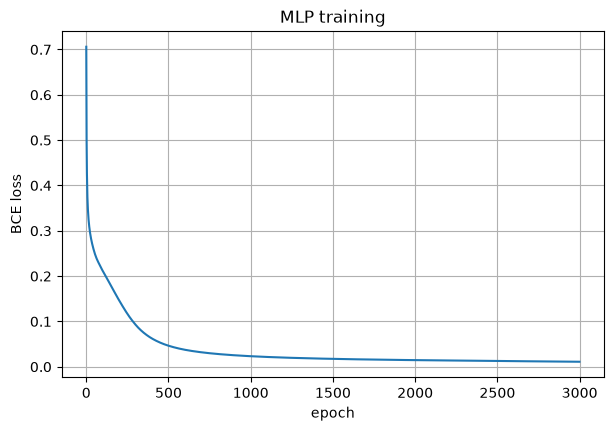

In [12]:
params = init_mlp(seed=0)
learning_rate = 0.5
losses2, snapshots = [], {}

for epoch in range(3000):
    y_hat, cache = forward_mlp(X2, params)
    losses2.append(bce_loss(y2.reshape(-1, 1), y_hat))
    grads = backward_mlp(y2, y_hat, cache, params)
    for k in params:
        params[k] -= learning_rate * grads[k]
    if epoch in (0, 100, 500, 2999):
        snapshots[epoch] = {k: v.copy() for k, v in params.items()}

acc = np.mean((forward_mlp(X2, params)[0].ravel() > 0.5) == y2)
print(f"final loss = {losses2[-1]:.4f}   accuracy = {acc:.1%}")

plt.plot(losses2)
plt.xlabel("epoch"); plt.ylabel("BCE loss"); plt.title("MLP training"); plt.show()

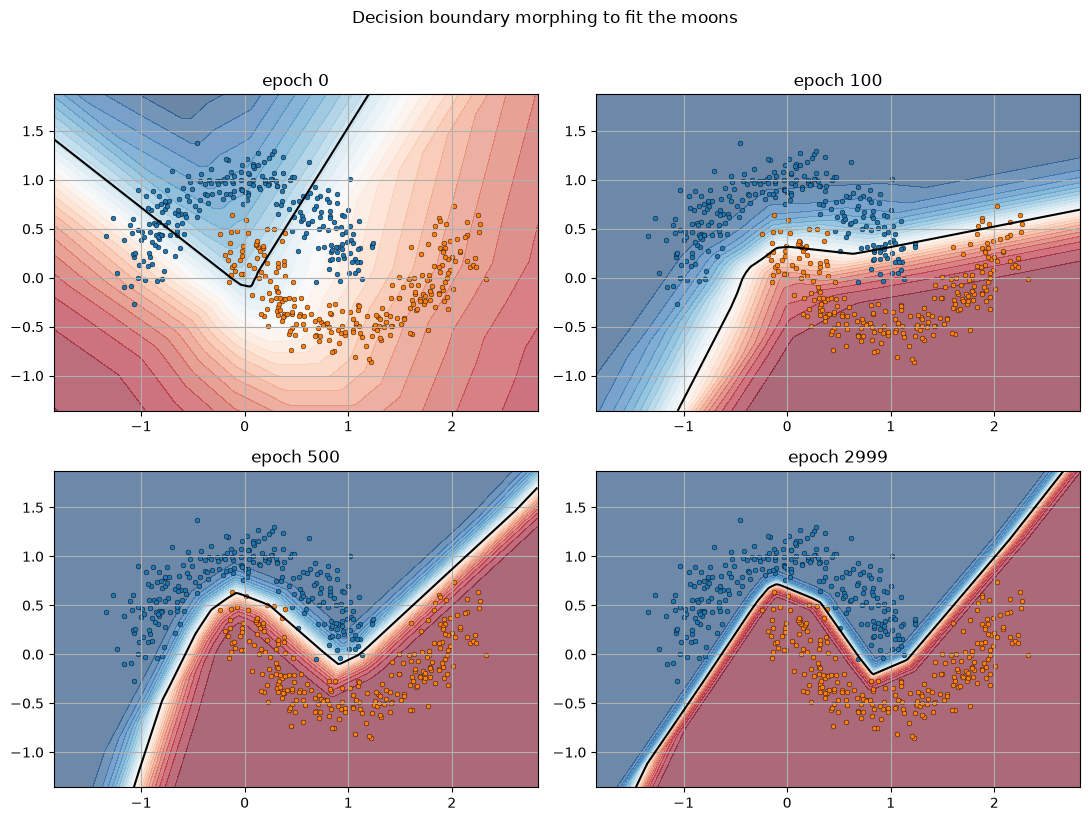

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
x_min, x_max = X2[:, 0].min() - .5, X2[:, 0].max() + .5
y_min, y_max = X2[:, 1].min() - .5, X2[:, 1].max() + .5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

for ax, (epoch, p) in zip(axes.ravel(), snapshots.items()):
    probs = forward_mlp(grid, p)[0].reshape(xx.shape)
    ax.contourf(xx, yy, probs, levels=25, cmap="RdBu_r", alpha=0.6)
    ax.contour(xx, yy, probs, levels=[0.5], colors="k", linewidths=1.5)
    ax.scatter(X2[y2 == 0, 0], X2[y2 == 0, 1], s=12, edgecolor="k", linewidth=0.3)
    ax.scatter(X2[y2 == 1, 0], X2[y2 == 1, 1], s=12, edgecolor="k", linewidth=0.3)
    ax.set_title(f"epoch {epoch}")
fig.suptitle("Decision boundary morphing to fit the moons", y=1.02)
plt.tight_layout(); plt.show()

## 2.6 Experiments (Module 2)

1. **Width:** retrain with `n_hidden = 2`, then `64`. How does the boundary's
   "resolution" change? With 2 hidden units, how many line segments can the
   boundary have?
2. **Kill the nonlinearity:** replace `relu(Z1)` with just `Z1` (identity) in the
   forward pass *and* remove the ReLU gate line in backprop. The model collapses
   to a straight line no matter how wide, because two stacked linear layers are
   still linear. Prove it to yourself with the plot.
3. **Bad init:** initialize all weights to exactly `0`. Training goes nowhere,
   because every hidden unit computes the same thing and receives the same
   gradient (the *symmetry problem*). This is why we initialize randomly.
4. **Sigmoid hidden layer:** swap ReLU for sigmoid in the hidden layer (its local
   gradient is `A1 * (1 - A1)`). Compare convergence speed over 3000 epochs.

---
# Module 3 — The Same Ideas in TensorFlow / Keras

🧠 **The intuition.** You have now personally written everything a framework
does, which means a framework will never be mysterious to you, only
convenient. Here is the translation table:

| You wrote (NumPy) | Keras equivalent |
|---|---|
| `forward_mlp` + weight dicts | `Sequential([Dense, Dense])` |
| `backward_mlp` (chain rule) | **autodiff**: recorded on a tape, derived automatically |
| `params[k] -= lr * grads[k]` | `optimizer` (SGD, Adam, ...) |
| your `for epoch` loop | `model.fit()` |
| `bce_loss` | `loss="binary_crossentropy"` |

Frameworks buy you: no hand-derived gradients (impossible to maintain at 50
layers), GPU execution, battle-tested optimizers, and a mature callback and
metrics layer. The *concepts* are exactly the ones you just implemented.

📐 **A new problem type: multi-class** (4 classes, 10 features). Two things
change versus binary classification. The output layer becomes 4 units with
**softmax**, turning scores into a probability distribution over classes:

$$\text{softmax}(z)_c = \frac{e^{z_c}}{\sum_{c'} e^{z_{c'}}}$$

And the loss becomes **sparse categorical cross-entropy**, which is BCE's
generalization to more than two classes; "sparse" just means the labels arrive
as integers `0..3` rather than one-hot vectors.

💻 **The code.** Build, compile, fit, evaluate: the four verbs, in that order.

In [14]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"   # hide TF's info-level C++ log spam

import tensorflow as tf
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

tf.random.set_seed(42)
print("TensorFlow", tf.__version__)

# make_classification builds a random n-class problem:
#   n_informative = features that actually carry class signal
#   n_redundant   = linear combinations of informative ones (correlated filler)
#   class_sep     = distance between class clusters (bigger = easier problem)
X3, y3 = make_classification(
    n_samples=2000, n_features=10, n_informative=6, n_redundant=2,
    n_classes=4, n_clusters_per_class=1, class_sep=1.5, random_state=42,
)

# Hold out 20% as a final test set the model never trains on.
# stratify=y3 keeps the class proportions identical in both splits.
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, stratify=y3, random_state=42)
print("train:", X3_train.shape, " test:", X3_test.shape, " classes:", np.unique(y3))

I0000 00:00:1786168961.092819   77945 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 2.21.0
train: (1600, 10)  test: (400, 10)  classes: [0 1 2 3]


I0000 00:00:1786168961.830832   77945 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 3.1 Build: the architecture in a few declarative lines

In [15]:
# Sequential = a plain stack: each layer's output feeds the next layer's input.
model3 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(10,)),             # declare input shape up front so Keras can size all weight matrices
    tf.keras.layers.Dense(32, activation="relu"),   # Dense = fully-connected: X @ W + b, then activation (our W1/b1 + relu)
    tf.keras.layers.Dense(16, activation="relu"),   # a second hidden layer: one more line, no new backprop code!
    tf.keras.layers.Dense(4, activation="softmax"), # 4 outputs that sum to 1 = a probability per class
])
model3.summary()   # table of layers, output shapes, and trainable parameter counts
# Param check, layer 1: 10 inputs * 32 units + 32 biases = 352. Verify the rest!

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 948 (3.70 KB)

 Trainable params: 948 (3.70 KB)

 Non-trainable params: 0 (0.00 B)

## 3.2 Compile: pick loss, optimizer, metrics

**Adam** is gradient descent with two upgrades: per-parameter adaptive step sizes
and momentum. It's the default choice in practice; plain SGD is what you wrote.

In [16]:
# compile() attaches the three training ingredients to the model:
model3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),  # the update rule, replacing our manual `w -= lr * grad`
    loss="sparse_categorical_crossentropy",  # what to minimize; "sparse" = labels are ints 0..3, not one-hot vectors
    metrics=["accuracy"],                    # extra numbers tracked per epoch (reported, never optimized)
)

## 3.3 Fit: the training loop you no longer write

`validation_split=0.2` holds out the last 20% of training data and evaluates on
it after every epoch. Watching *both* curves is how you detect overfitting
(Module 4 makes this the star of the show).

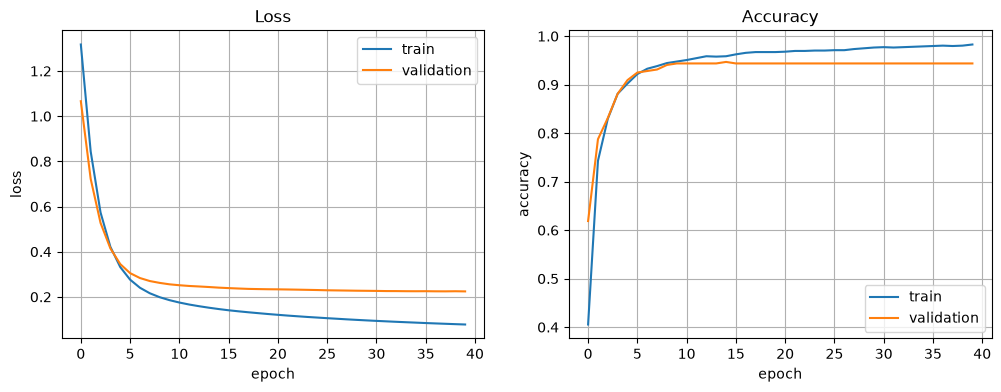

In [17]:
history = model3.fit(
    X3_train, y3_train,
    epochs=40,               # full passes over the training data
    batch_size=32,           # one gradient step per 32 samples (mini-batch SGD), not per epoch like our NumPy loop
    validation_split=0.2,    # hold out the last 20% of train data, score it after every epoch
    verbose=0,               # silence per-epoch logs; we plot instead
)
# fit() returns a History object. history.history is a dict of per-epoch lists:
# "loss"/"accuracy" (training) and "val_loss"/"val_accuracy" (held-out validation).

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history["loss"], label="train")
ax1.plot(history.history["val_loss"], label="validation")
ax1.set_xlabel("epoch"); ax1.set_ylabel("loss"); ax1.legend(); ax1.set_title("Loss")
ax2.plot(history.history["accuracy"], label="train")
ax2.plot(history.history["val_accuracy"], label="validation")
ax2.set_xlabel("epoch"); ax2.set_ylabel("accuracy"); ax2.legend(); ax2.set_title("Accuracy")
plt.show()

## 3.4 Evaluate with Scikit-Learn

Frameworks interoperate: Keras predicts, Scikit-Learn scores. `predict` returns
an (n, 4) matrix of softmax probabilities; `argmax` picks the winning class.

test accuracy: 0.9525
              precision    recall  f1-score   support

           0       0.97      0.94      0.95       100
           1       0.92      0.95      0.94       100
           2       0.99      0.95      0.97       100
           3       0.93      0.97      0.95       100

    accuracy                           0.95       400
   macro avg       0.95      0.95      0.95       400
weighted avg       0.95      0.95      0.95       400



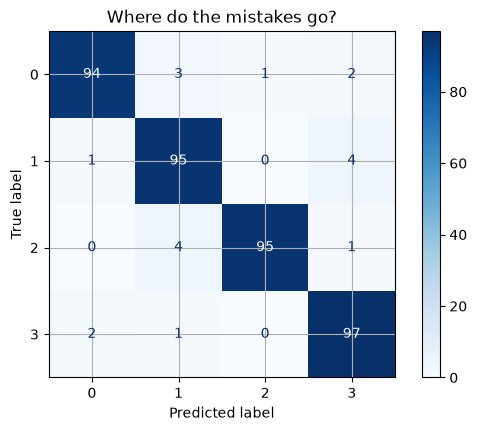

In [18]:
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

probs = model3.predict(X3_test, verbose=0)     # (400, 4): one softmax distribution per test sample
y3_pred = probs.argmax(axis=1)                 # index of the largest probability = predicted class label

print("test accuracy:", accuracy_score(y3_test, y3_pred))
print(classification_report(y3_test, y3_pred))   # precision / recall / F1, per class

# from_predictions computes the confusion matrix AND draws it in one call
ConfusionMatrixDisplay.from_predictions(y3_test, y3_pred, cmap="Blues")
plt.title("Where do the mistakes go?"); plt.show()

## 3.5 Experiments (Module 3)

1. **Recreate Module 2 in Keras:** one hidden `Dense(16, activation="relu")`, one
   `Dense(1, activation="sigmoid")`, loss `"binary_crossentropy"`, optimizer
   `SGD(learning_rate=0.5)`. Train it on the moons data (`X2`, `y2`) and confirm
   you get the same ~99% accuracy as your NumPy version.
2. **Adam vs SGD:** recompile with `optimizer="sgd"` and retrain. Compare the loss
   curves. This is why adaptive optimizers won.
3. **Harder data:** drop `class_sep` to `0.5` and regenerate. What happens to the
   gap between train and validation accuracy?

---
# Module 4 — Hyperparameters & Overfitting

🧠 **The intuition.** Architecture and loss are usually the easy part. In
practice you spend your time on three dials: *learning rate*, *capacity*
(depth × width), and *regularization*. The only reliable way to learn what they
do is to turn each one until something breaks, and this module breaks each one
visibly, on a regression task.

📐 **The setup.** A sine wave with Gaussian noise on top:

$$y = \sin(2\pi x) + \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0, 0.25^2)$$

The noise is the point. A good model should learn the sine wave and **ignore**
the noise; an overfit model memorizes the noise itself. Because we wrote the
generator, we know exactly which part of the target is signal and which is not.
That is a luxury you never get on real data, and it is the reason this
experiment runs on synthetic data.

💻 **The code.**

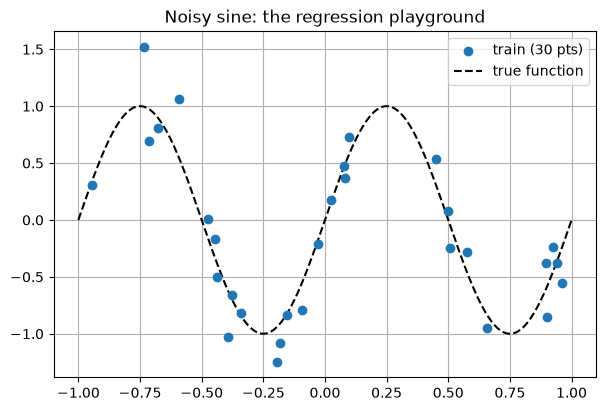

In [19]:
def make_sine_data(n, seed):
    r = np.random.default_rng(seed)
    x = np.sort(r.uniform(-1, 1, size=(n, 1)), axis=0)
    y = np.sin(2 * np.pi * x) + r.normal(scale=0.25, size=(n, 1))
    return x.astype("float32"), y.astype("float32")

x_grid = np.linspace(-1, 1, 300, dtype="float32").reshape(-1, 1)
x_tr, y_tr = make_sine_data(30, seed=1)      # tiny training set (deliberately!)
x_va, y_va = make_sine_data(200, seed=2)     # validation set

plt.scatter(x_tr, y_tr, label="train (30 pts)", zorder=3)
plt.plot(x_grid, np.sin(2 * np.pi * x_grid), "k--", label="true function")
plt.legend(); plt.title("Noisy sine: the regression playground"); plt.show()

## 4.1 Learning rate: the most important single hyperparameter

Same model, same data, two learning rates with plain SGD:

| Learning rate | What happens |
|---|---|
| 0.3 | steady convergence to a low loss |
| 1.0 | every step overshoots the minimum, and the loss *diverges* within a few epochs |

The third failure mode, a rate so small that training crawls and you would wait
forever, is left for you to produce in the experiments below.

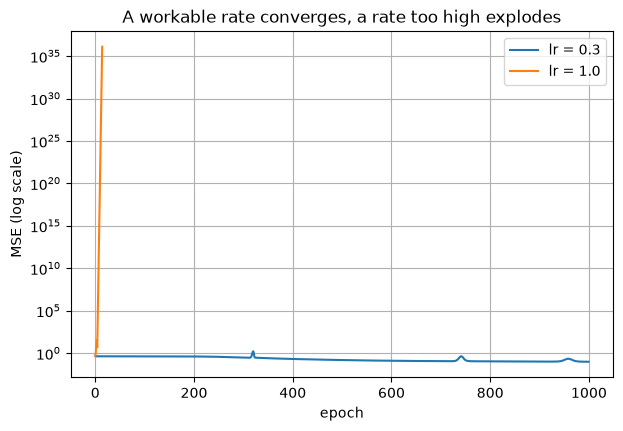

lr=0.3    final loss = 0.0964
lr=1.0    final loss = nan


In [20]:
def small_regressor():
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(1,)),
        tf.keras.layers.Dense(32, activation="tanh"),
        tf.keras.layers.Dense(1),
    ])

histories = {}
for lr in [0.3, 1.0]:
    tf.random.set_seed(0)    # identical weight init every time, so lr is the ONLY difference
    m = small_regressor()
    # Plain SGD (exactly your Module 1 update rule) and MSE, the standard regression loss
    m.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=lr), loss="mse")
    h = m.fit(x_tr, y_tr, epochs=1000, verbose=0)
    histories[lr] = h.history["loss"]

for lr, loss in histories.items():
    plt.plot(loss, label=f"lr = {lr}")
plt.yscale("log")   # log scale fits divergence (NaN/huge) and crawling (tiny changes) on one plot
plt.xlabel("epoch"); plt.ylabel("MSE (log scale)"); plt.legend()
plt.title("A workable rate converges, a rate too high explodes"); plt.show()
for lr, loss in histories.items():
    print(f"lr={lr:<6} final loss = {loss[-1]:.4f}")

## 4.2 Overfitting: big model, tiny dataset

An oversized network (3×256 units, ~130k parameters) on 30 points has more than
enough capacity to route the curve through every noisy sample. Watch the two
loss curves **diverge**: train keeps dropping while validation bottoms out and
climbs back up. That gap *is* overfitting.

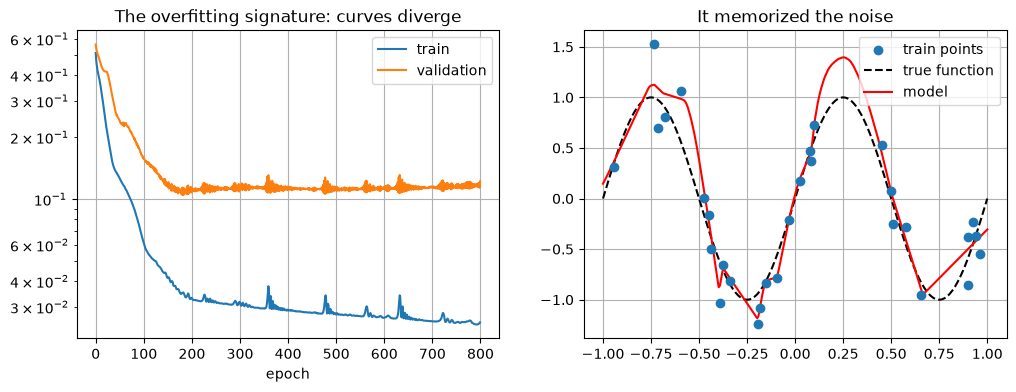

In [21]:
def big_regressor(l2=0.0, dropout=0.0):
    # kernel_regularizer adds l2 * sum(W^2) to the loss for that layer's weight matrix
    reg = tf.keras.regularizers.l2(l2) if l2 > 0 else None
    layers = [tf.keras.layers.Input(shape=(1,))]
    for _ in range(3):
        layers.append(tf.keras.layers.Dense(256, activation="relu", kernel_regularizer=reg))
        if dropout > 0:
            # Dropout zeroes this fraction of activations at random, each training batch.
            # It is a layer with no weights, and it is inactive at inference time.
            layers.append(tf.keras.layers.Dropout(dropout))
    layers.append(tf.keras.layers.Dense(1))   # no activation = linear output, standard for regression
    return tf.keras.Sequential(layers)

tf.random.set_seed(0)
overfit_model = big_regressor()
overfit_model.compile(optimizer="adam", loss="mse")   # string "adam" = Adam with default lr 1e-3
# validation_data: score this fixed, separate (x, y) set after each epoch
# (unlike validation_split, which carves the holdout out of the training data)
h_over = overfit_model.fit(x_tr, y_tr, validation_data=(x_va, y_va),
                           epochs=800, verbose=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(h_over.history["loss"], label="train")
ax1.plot(h_over.history["val_loss"], label="validation")
ax1.set_yscale("log"); ax1.legend(); ax1.set_xlabel("epoch")
ax1.set_title("The overfitting signature: curves diverge")

ax2.scatter(x_tr, y_tr, zorder=3, label="train points")
ax2.plot(x_grid, np.sin(2 * np.pi * x_grid), "k--", label="true function")
ax2.plot(x_grid, overfit_model.predict(x_grid, verbose=0), "r", label="model")
ax2.legend(); ax2.set_title("It memorized the noise")
plt.show()

## 4.3 Regularization: fighting back

Two standard weapons, both one-liners in Keras:

- **L2 (weight decay):** add $\lambda \sum w^2$ to the loss, so big weights get
  taxed, forcing smoother functions.
- **Dropout:** during training, randomly zero a fraction of activations each
  batch. No unit can rely on any other specific unit, so the network can't build
  fragile co-adapted noise detectors. (Disabled automatically at inference.)

Same oversized architecture, same 30 points, now regularized.

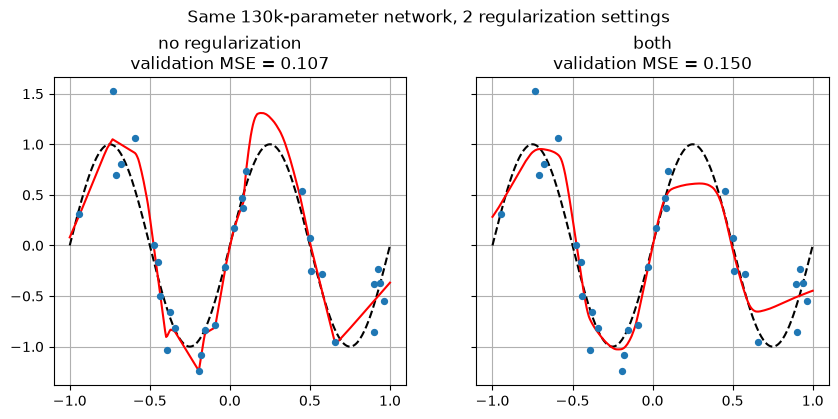

In [22]:
configs = {
    "no regularization": dict(l2=0.0, dropout=0.0),
    # "L2 (1e-3)":         dict(l2=1e-3, dropout=0.0),
    # "Dropout (0.3)":     dict(l2=0.0, dropout=0.3),
    "both":              dict(l2=1e-3, dropout=0.3),
}

fig, axes = plt.subplots(1, len(configs), figsize=(5 * len(configs), 4), sharey=True)
for ax, (name, cfg) in zip(axes, configs.items()):
    tf.random.set_seed(0)
    m = big_regressor(**cfg)
    m.compile(optimizer="adam", loss="mse")
    m.fit(x_tr, y_tr, epochs=800, verbose=0)
    val_mse = m.evaluate(x_va, y_va, verbose=0)
    ax.scatter(x_tr, y_tr, zorder=3, s=18)
    ax.plot(x_grid, np.sin(2 * np.pi * x_grid), "k--")
    ax.plot(x_grid, m.predict(x_grid, verbose=0), "r")
    ax.set_title(f"{name}\nvalidation MSE = {val_mse:.3f}")
plt.suptitle(f"Same 130k-parameter network, {len(configs)} regularization settings", y=1.05)
plt.show()

## 4.4 Experiments (Module 4)

1. **More data beats everything:** rerun 4.2 with `make_sine_data(500, seed=1)`
   as training data. Overfitting largely vanishes with the *same* huge model,
   since capacity is only a problem relative to dataset size.
2. **Sweep L2:** try `l2` in `[1e-5, 1e-3, 1e-1]`. At `1e-1`, the model
   *underfits*: regularization is a dial, not a switch.
3. **Early stopping preview:** from the 4.2 loss plot, read off the epoch where
   `val_loss` is lowest. Retrain with exactly that many epochs and compare
   validation MSE. Module 5 automates this with a callback.
4. **Dropout at eval:** call `overfit_model(x_grid, training=True)` a few times
   on a dropout model and plot. The prediction jitters, which is dropout still
   firing; `training=False` (the default in `.predict`) is why inference is stable.

---
# Module 5 — Mini-Project: Tabular Deep Learning Pipeline

🧠 **The intuition.** Everything so far assumed a clean numeric matrix `X`.
Real data is a messy DataFrame: numbers on wildly different scales, strings for
categories, and columns a network cannot consume at all. So a real pipeline has
two halves, a preprocessing stage that turns the mess into a float matrix, and
the model you already know:

```
raw DataFrame ──▶ ColumnTransformer ──▶ clean float matrix ──▶ Keras model
                  (Scikit-Learn)                                (TensorFlow)
```

**The scenario:** telecom customer churn. We *simulate* the dataset, which has
a side benefit worth more than realism: we planted the true signal ourselves,
so in section 5.5 we can check whether the model actually found it.

💻 **The code.**

## 5.1 Simulate the churn dataset

5,000 customers. Churn probability truly depends on: short tenure, month-to-month
contracts, many support calls, and high monthly charges. Plus noise, because real
churn is never fully predictable.

In [23]:
import pandas as pd

def simulate_churn(n=5000, seed=7):
    r = np.random.default_rng(seed)
    df = pd.DataFrame({
        "tenure_months":   r.integers(1, 72, size=n),           # uniform random ints in [1, 72)
        "monthly_charges": np.round(r.uniform(20, 120, size=n), 2),
        "support_calls":   r.poisson(1.5, size=n),              # count data: most customers 0-3 calls
        "contract":        r.choice(["month-to-month", "one-year", "two-year"],
                                    size=n, p=[0.55, 0.25, 0.20]),   # categorical draw, p = probability of each option
        "payment_method":  r.choice(["credit_card", "bank_transfer", "e_check", "mail_check"],
                                    size=n, p=[0.30, 0.25, 0.30, 0.15]),
    })
    # Ground-truth churn logit (the "physics" of this simulated world).
    # .map(dict) looks up each row's category in the dict -> its logit contribution.
    logit = (
        -0.5
        - 0.045 * df["tenure_months"]                # longer tenure -> less churn
        + 0.015 * (df["monthly_charges"] - 70)       # pricier plans -> more churn
        + 0.55  * df["support_calls"]                # strongest single driver
        + df["contract"].map({"month-to-month": 1.2, "one-year": 0.0, "two-year": -1.0})
        + df["payment_method"].map({"e_check": 0.4, "credit_card": 0.0,
                                    "bank_transfer": 0.0, "mail_check": 0.2})
    )
    # Convert logit -> probability with our own Module 1 sigmoid, then flip a
    # biased coin per customer. The noise is realistic: churn is never certain.
    df["churn"] = (r.uniform(size=n) < sigmoid(logit.values)).astype(int)
    return df

churn = simulate_churn()
print(f"churn rate: {churn['churn'].mean():.1%}")
churn.head()

churn rate: 37.6%


,tenure_months,monthly_charges,support_calls,contract,payment_method,churn
0,68,81.44,2,one-year,credit_card,0
1,45,86.39,2,one-year,credit_card,0
2,49,81.39,1,two-year,e_check,0
3,64,45.62,2,month-to-month,e_check,1
4,42,57.63,2,month-to-month,mail_check,0


## 5.2 Preprocess with a ColumnTransformer

- **Numeric → `StandardScaler`.** Neural nets care about scale: `tenure` spans
  1–72 while a scaled feature spans ~±2. Unscaled inputs make the loss surface
  badly conditioned and gradient descent zig-zags. (Tree models don't care;
  neural nets very much do.)
- **Categorical → `OneHotEncoder`.** Strings become indicator columns.

Critical discipline: **fit the transformer on training data only**, then `transform`
the test set. Fitting on all data leaks test-set statistics into training.

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = ["tenure_months", "monthly_charges", "support_calls"]
categorical_features = ["contract", "payment_method"]

# ColumnTransformer applies a different transformer to each group of columns,
# then concatenates the results into one matrix. Each entry: (name, transformer, columns).
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),   # z-score each column: (x - mean) / std
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    # OneHotEncoder: one 0/1 indicator column per category.
    # handle_unknown="ignore": a category never seen during fit encodes as all
    # zeros at transform time, instead of raising an error in production.
])

X5 = churn.drop(columns="churn")
y5 = churn["churn"].values

X5_train_raw, X5_test_raw, y5_train, y5_test = train_test_split(
    X5, y5, test_size=0.2, stratify=y5, random_state=42)

X5_train = preprocessor.fit_transform(X5_train_raw)   # fit = learn means/stds/category lists, then transform; the train split ONLY
X5_test  = preprocessor.transform(X5_test_raw)        # transform only: reuse the train statistics on unseen data

print("raw columns:", list(X5.columns))
print("matrix shape after preprocessing:", X5_train.shape)
# get_feature_names_out(): names of the generated columns, e.g. "cat__contract_one-year"
print("feature names:", list(preprocessor.get_feature_names_out()))

raw columns: ['tenure_months', 'monthly_charges', 'support_calls', 'contract', 'payment_method']
matrix shape after preprocessing: (4000, 10)
feature names: ['num__tenure_months', 'num__monthly_charges', 'num__support_calls', 'cat__contract_month-to-month', 'cat__contract_one-year', 'cat__contract_two-year', 'cat__payment_method_bank_transfer', 'cat__payment_method_credit_card', 'cat__payment_method_e_check', 'cat__payment_method_mail_check']


## 5.3 Model + early stopping

`EarlyStopping` watches `val_loss` and stops when it hasn't improved for
`patience` epochs, then rolls the weights back to the best epoch
(`restore_best_weights=True`). We can set `epochs=200` and let the callback
decide, which is Module 4's overfitting lesson, automated.

stopped after 41 epochs (best weights restored from epoch 26)


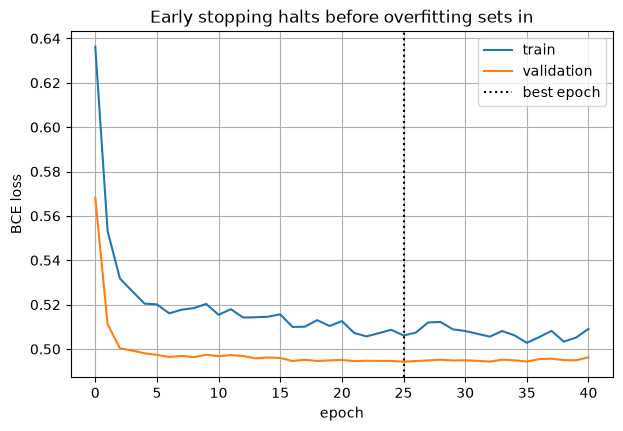

In [25]:
tf.random.set_seed(42)
n_features = X5_train.shape[1]

model5 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(n_features,)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1, activation="sigmoid"),   # Module 1's neuron, on learned features
])
model5.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
               loss="binary_crossentropy",
               # AUC = area under the ROC curve: threshold-independent, more
               # informative than accuracy when classes are imbalanced (38% churn)
               metrics=[tf.keras.metrics.AUC(name="auc")])

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",           # the quantity to watch after each epoch
    patience=15,                  # tolerate 15 epochs without improvement before stopping
    restore_best_weights=True)    # then roll the model back to its best epoch

history5 = model5.fit(
    X5_train, y5_train,
    validation_split=0.2,
    epochs=200, batch_size=64,    # 200 is just a ceiling; the callback decides the real stop
    callbacks=[early_stop],       # callbacks hook into the training loop between epochs
    verbose=0,
)
print(f"stopped after {len(history5.history['loss'])} epochs "
      f"(best weights restored from epoch {np.argmin(history5.history['val_loss']) + 1})")

plt.plot(history5.history["loss"], label="train")
plt.plot(history5.history["val_loss"], label="validation")
plt.axvline(np.argmin(history5.history["val_loss"]), color="k", ls=":", label="best epoch")
plt.xlabel("epoch"); plt.ylabel("BCE loss"); plt.legend()
plt.title("Early stopping halts before overfitting sets in"); plt.show()

## 5.4 Final evaluation on held-out customers

test accuracy: 0.723
test ROC AUC : 0.783
              precision    recall  f1-score   support

      stayed       0.77      0.80      0.78       624
     churned       0.64      0.59      0.62       376

    accuracy                           0.72      1000
   macro avg       0.70      0.70      0.70      1000
weighted avg       0.72      0.72      0.72      1000



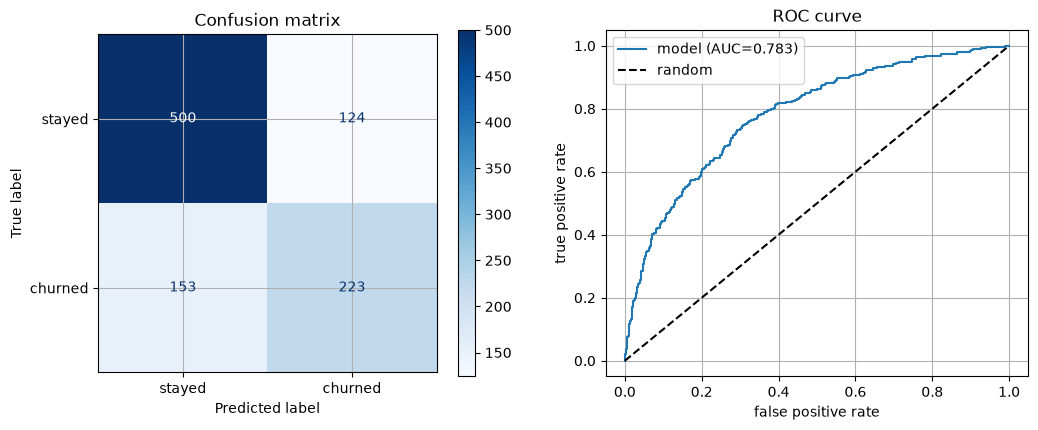

In [26]:
from sklearn.metrics import roc_auc_score, roc_curve

churn_probs = model5.predict(X5_test, verbose=0).ravel()   # (n, 1) -> flat (n,) probability vector
churn_pred = (churn_probs > 0.5).astype(int)               # threshold at 0.5 to get hard 0/1 labels

print(f"test accuracy: {accuracy_score(y5_test, churn_pred):.3f}")
print(f"test ROC AUC : {roc_auc_score(y5_test, churn_probs):.3f}")
print(classification_report(y5_test, churn_pred, target_names=["stayed", "churned"]))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y5_test, churn_pred, display_labels=["stayed", "churned"], cmap="Blues", ax=ax1)
ax1.set_title("Confusion matrix")
# roc_curve sweeps every possible threshold and returns the false/true
# positive rate at each one: the trade-off curve, not a single number
fpr, tpr, _ = roc_curve(y5_test, churn_probs)
ax2.plot(fpr, tpr, label=f"model (AUC={roc_auc_score(y5_test, churn_probs):.3f})")
ax2.plot([0, 1], [0, 1], "k--", label="random")
ax2.set_xlabel("false positive rate"); ax2.set_ylabel("true positive rate")
ax2.legend(); ax2.set_title("ROC curve")
plt.show()

## 5.5 Did it find the planted signal?

Because we wrote the simulator, we can check the model against ground truth:
churn should rise with support calls and fall with tenure, and month-to-month
contracts should churn most. A quick probe: sweep one feature while holding the
others at a fixed "typical customer" profile.

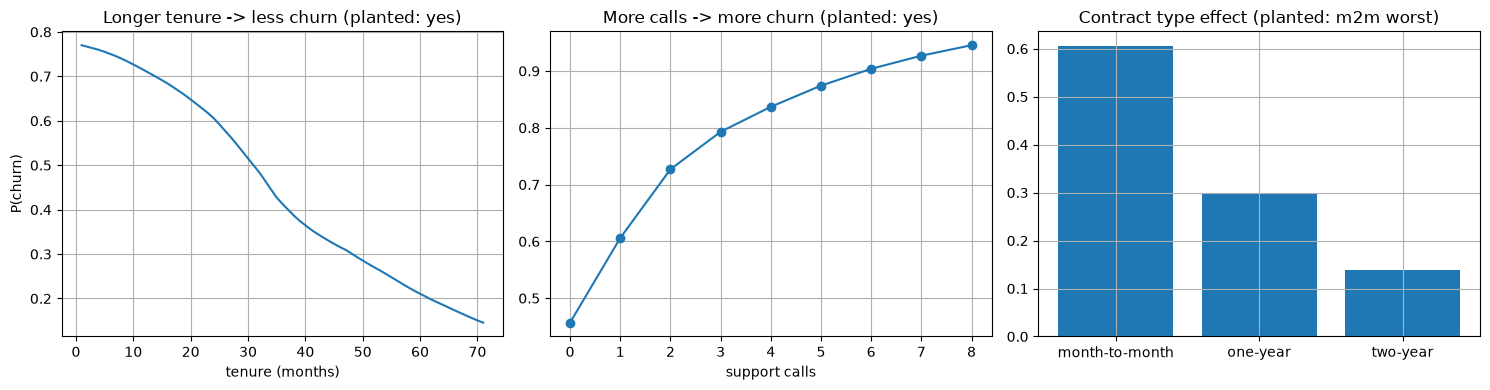

In [27]:
def probe(feature, values):
    base = pd.DataFrame({
        "tenure_months": [24], "monthly_charges": [70.0], "support_calls": [1],
        "contract": ["month-to-month"], "payment_method": ["credit_card"],
    })
    rows = pd.concat([base] * len(values), ignore_index=True)   # repeat the base profile once per probe value
    rows[feature] = values                                      # ...then vary ONLY the feature being probed
    # Reuse the fitted preprocessor: raw DataFrame -> matrix -> churn probabilities
    return model5.predict(preprocessor.transform(rows), verbose=0).ravel()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
tenures = np.arange(1, 72)
axes[0].plot(tenures, probe("tenure_months", tenures))
axes[0].set_xlabel("tenure (months)"); axes[0].set_ylabel("P(churn)")
axes[0].set_title("Longer tenure -> less churn (planted: yes)")

calls = np.arange(0, 9)
axes[1].plot(calls, probe("support_calls", calls), marker="o")
axes[1].set_xlabel("support calls"); axes[1].set_title("More calls -> more churn (planted: yes)")

contracts = ["month-to-month", "one-year", "two-year"]
axes[2].bar(contracts, probe("contract", contracts))
axes[2].set_title("Contract type effect (planted: m2m worst)")
plt.tight_layout(); plt.show()

## 5.6 Experiments (Module 5)

1. **Beat the baseline:** train `sklearn.linear_model.LogisticRegression` on the
   same preprocessed matrices. On this dataset the ground truth is *nearly*
   linear in the features, so how much does depth actually buy? (An important
   real-world lesson for tabular data.)
2. **Break the pipeline on purpose:** skip `StandardScaler` (pass numerics
   through raw) and retrain. Compare epochs-to-converge and final AUC.
3. **Nonlinear ground truth:** add an interaction to the simulator, e.g.
   `+ 0.8 * (support_calls >= 3) * (contract == "month-to-month")`, regenerate,
   and re-run experiment 1. Now the network should pull ahead of logistic
   regression.
4. **Threshold tuning:** retention campaigns have asymmetric costs. Sweep the 0.5
   decision threshold, plot precision vs recall, and pick a threshold for "we can
   only afford to contact 20% of customers".

---
# Wrap-Up

| You built | The transferable lesson |
|---|---|
| A single neuron + hand-derived BCE gradients | Sigmoid and BCE are paired because $\partial L/\partial z$ collapses to $\hat{y} - y$ |
| An MLP with hand-written backprop | Backpropagation is the chain rule, applied layer by layer, passing one message backwards per layer |
| Gradient checking | Never trust an analytic gradient you have not compared against a numerical one |
| The same model in Keras | A framework replaces your loop, your gradients, and your optimizer, but not your understanding of them |
| Learning-rate and capacity sweeps | Overfitting is capacity measured *relative to dataset size*; regularization is a dial, not a switch |
| A ColumnTransformer → Keras pipeline | Fit preprocessing on training data only; unscaled inputs make gradient descent zig-zag |

You built the atom (Module 1), the molecule (Module 2), then let the factory
take over (Modules 3–5). Everything larger in deep learning is these same
parts, repeated.

### Where to go next

Convolutional networks (`Conv2D`) run the same training loop on real images with
one new layer type, and they fix the dense layer's blind spot, since flattening
an image throws away the fact that pixel $(5, 6)$ sits next to pixel $(5, 7)$.
To watch autodiff do the work you did by hand, re-derive Module 2's backprop
with `tf.GradientTape` and compare gradients against `backward_mlp`. For theory,
read *Deep Learning* (Goodfellow et al.); for practice, the Keras docs.